<a href="https://colab.research.google.com/github/anaPierrout/Fase1FIAP/blob/main/eda_nps_preditivo_spark_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória dos Dados (EDA)
## Case NPS Preditivo em E-commerce

Este notebook resolve a EDA do Tech Challenge com foco em **negócio e storytelling**, usando **Spark SQL** para leitura, preparação, agregações e feature engineering.

**Objetivo:** identificar quais fatores operacionais mais prejudicam a satisfação do cliente e quais sinais antecipam clientes com maior risco de virarem detratores.

**Target:** `is_detrator = 1` quando `nps_score <= 6`; `is_detrator = 0` quando `nps_score > 6`.

> Observação: a base enviada possui `nps_score` com casas decimais. Para não descartar registros, a categorização foi adaptada para cortes contínuos: **Detrator <= 6**, **Neutro > 6 e < 9**, **Promotor >= 9**.

## 1. Preparação do ambiente

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("EDA_NPS_Preditivo").getOrCreate()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Leitura da base e visão geral

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_path = "/content/drive/MyDrive/TECH CHALLENGE/desafio_nps_fase_1.csv"

df_spark = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(csv_path)
)

df_spark.createOrReplaceTempView("Base_nps")

print(f"Linhas: {df_spark.count()}")
print(f"Colunas: {len(df_spark.columns)}")
df_spark.printSchema()
spark.sql("SELECT * FROM Base_nps LIMIT 5").show(truncate=False)

Linhas: 2500
Colunas: 19
root
 |-- customer_id: integer (nullable = true)
 |-- customer_age: integer (nullable = true)
 |-- customer_region: string (nullable = true)
 |-- customer_tenure_months: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- order_value: double (nullable = true)
 |-- items_quantity: integer (nullable = true)
 |-- discount_value: double (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- delivery_time_days: integer (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- delivery_attempts: integer (nullable = true)
 |-- customer_service_contacts: integer (nullable = true)
 |-- resolution_time_days: integer (nullable = true)
 |-- nps_score: double (nullable = true)
 |-- repeat_purchase_30d: integer (nullable = true)
 |-- complaints_count: integer (nullable = true)
 |-- csat_internal_score: double (nullable = true)

+-----------+------------+---------------+----

In [ ]:
linhas = df_spark.count()
colunas = len(df_spark.columns)
linhas_duplicadas = linhas - df_spark.dropDuplicates().count()
order_id_duplicados = linhas - df_spark.select("order_id").dropDuplicates().count()
customer_id_duplicados = linhas - df_spark.select("customer_id").dropDuplicates().count()

print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")
print(f"Linhas duplicadas: {linhas_duplicadas}")
print(f"order_id duplicados: {order_id_duplicados}")
print(f"customer_id duplicados: {customer_id_duplicados}")

null_expr = ",\n".join([
    f"SUM(CASE WHEN `{c}` IS NULL THEN 1 ELSE 0 END) AS `{c}`"
    for c in df_spark.columns
])
spark.sql(f"SELECT {null_expr} FROM Base_nps").show(truncate=False)

Linhas: 2500
Colunas: 19
Linhas duplicadas: 0
order_id duplicados: 0
customer_id duplicados: 0
+-----------+------------+---------------+----------------------+--------+-----------+--------------+--------------+--------------------+------------------+-------------------+-------------+-----------------+-------------------------+--------------------+---------+-------------------+----------------+-------------------+
|customer_id|customer_age|customer_region|customer_tenure_months|order_id|order_value|items_quantity|discount_value|payment_installments|delivery_time_days|delivery_delay_days|freight_value|delivery_attempts|customer_service_contacts|resolution_time_days|nps_score|repeat_purchase_30d|complaints_count|csat_internal_score|
+-----------+------------+---------------+----------------------+--------+-----------+--------------+--------------+--------------------+------------------+-------------------+-------------+-----------------+-------------------------+--------------------+----

### Leitura executiva da preparação

A base possui **2.500 pedidos**, **19 colunas**, sem valores nulos, sem linhas duplicadas e sem `order_id` ou `customer_id` repetido. Portanto, não foi preciso tratamento de qualidade de dados para realizar a EDA.

## 3. Criação da variável alvo e categorias de NPS

In [ ]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW nps_eda AS
SELECT
    *,
    CASE WHEN nps_score <= 6 THEN 1 ELSE 0 END AS is_detrator,
    CASE
        WHEN nps_score <= 6 THEN 'Detrator'
        WHEN nps_score < 9 THEN 'Neutro'
        ELSE 'Promotor'
    END AS nps_category,
    CASE
        WHEN delivery_delay_days = 0 THEN '0 dias'
        WHEN delivery_delay_days = 1 THEN '1 dia'
        WHEN delivery_delay_days = 2 THEN '2 dias'
        ELSE '3+ dias'
    END AS faixa_atraso,
    CASE
        WHEN customer_service_contacts = 0 THEN '0 contatos'
        WHEN customer_service_contacts = 1 THEN '1 contato'
        WHEN customer_service_contacts = 2 THEN '2 contatos'
        ELSE '3+ contatos'
    END AS faixa_contatos,
    CASE
        WHEN complaints_count = 0 THEN '0'
        WHEN complaints_count BETWEEN 1 AND 2 THEN '1-2'
        WHEN complaints_count BETWEEN 3 AND 4 THEN '3-4'
        WHEN complaints_count BETWEEN 5 AND 6 THEN '5-6'
        ELSE '7+'
    END AS faixa_reclamacoes,
    CASE
        WHEN resolution_time_days = 0 THEN '0 dias'
        WHEN resolution_time_days BETWEEN 1 AND 3 THEN '1-3 dias'
        WHEN resolution_time_days BETWEEN 4 AND 6 THEN '4-6 dias'
        WHEN resolution_time_days BETWEEN 7 AND 9 THEN '7-9 dias'
        ELSE '10+ dias'
    END AS faixa_resolucao,
    CASE
        WHEN customer_age <= 25 THEN '18-25'
        WHEN customer_age <= 35 THEN '26-35'
        WHEN customer_age <= 45 THEN '36-45'
        WHEN customer_age <= 55 THEN '46-55'
        WHEN customer_age <= 65 THEN '56-65'
        ELSE '66+'
    END AS faixa_idade,
    CASE
        WHEN customer_tenure_months <= 6 THEN '0-6m'
        WHEN customer_tenure_months <= 12 THEN '7-12m'
        WHEN customer_tenure_months <= 24 THEN '13-24m'
        WHEN customer_tenure_months <= 60 THEN '25-60m'
        ELSE '60m+'
    END AS faixa_relacionamento
FROM Base_nps
""")

spark.sql("""
SELECT
    nps_category,
    COUNT(*) AS qtd_clientes,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS percentual,
    ROUND(AVG(nps_score), 2) AS media_nps
FROM nps_eda
GROUP BY nps_category
ORDER BY CASE nps_category WHEN 'Detrator' THEN 1 WHEN 'Neutro' THEN 2 ELSE 3 END
""").show()

spark.sql("""
SELECT
    ROUND(AVG(nps_score),2) AS media_geral
FROM nps_eda
""").show()

spark.sql("""
SELECT
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS percentual
FROM nps_eda
""").show()

+------------+------------+----------+---------+
|nps_category|qtd_clientes|percentual|media_nps|
+------------+------------+----------+---------+
|    Detrator|        1851|      74.0|     3.26|
|      Neutro|         539|      21.6|     7.16|
|    Promotor|         110|       4.4|     9.61|
+------------+------------+----------+---------+

+-----------+
|media_geral|
+-----------+
|       4.38|
+-----------+



In [ ]:
nps_final = spark.sql("""
SELECT
    nps_category,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS percentual
FROM nps_eda
GROUP BY nps_category
""").toPandas()

promotores = nps_final[nps_final['nps_category'] == 'Promotor']['percentual'].iloc[0]
detrator = nps_final[nps_final['nps_category'] == 'Detrator']['percentual'].iloc[0]

nps_final_score = promotores - detrator
print(f"NPS final: {nps_final_score}")

NPS final: -69.6


### Leitura executiva do target

| Categoria | Clientes | % da base | Interpretação |
|---|---:|---:|---|
| Detrator | 1.851 | 74,0% | Grupo prioritário para ações preventivas |
| Neutro | 539 | 21,6% | Clientes intermediários, ainda recuperáveis |
| Promotor | 110 | 4,4% | Clientes com melhor experiência |

O NPS médio geral é **4,38**, e o NPS final estimado pela regra `% promotores - % detratores` é **-69,6**.

## 4. Funções auxiliares

In [ ]:
def sql_to_pandas(query: str) -> pd.DataFrame:
    return spark.sql(query).toPandas()

def add_labels(ax, fmt="{:.0f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3)

## 5. Distribuição do NPS

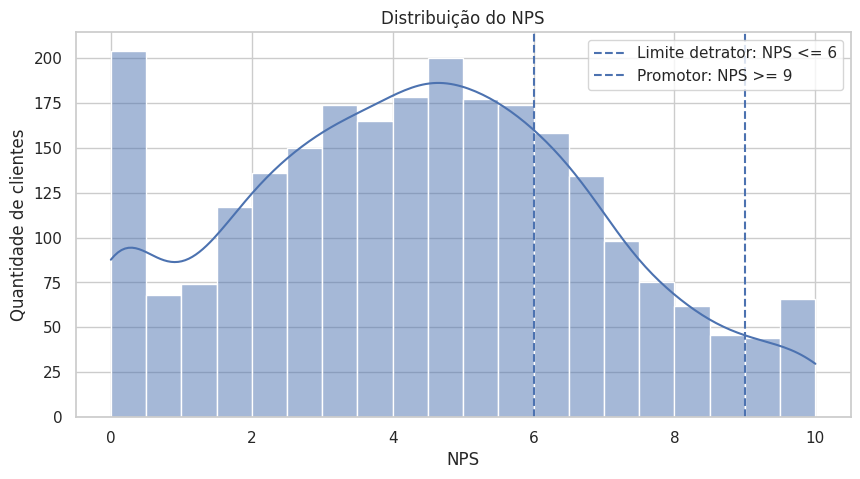

In [ ]:
nps_pd = sql_to_pandas("SELECT nps_score FROM nps_eda")

plt.figure(figsize=(10, 5))
sns.histplot(data=nps_pd, x="nps_score", bins=20, kde=True)
plt.axvline(6, linestyle="--", label="Limite detrator: NPS <= 6")
plt.axvline(9, linestyle="--", label="Promotor: NPS >= 9")
plt.title("Distribuição do NPS")
plt.xlabel("NPS")
plt.ylabel("Quantidade de clientes")
plt.legend()
plt.show()

### Storytelling

A distribuição mostra forte concentração nas notas baixas e médias. Em linguagem operacional: a empresa não tem apenas casos isolados de insatisfação; ela tem um volume alto de clientes que terminaram a jornada com percepção ruim.

## 6. Distribuição de detratores, neutros e promotores

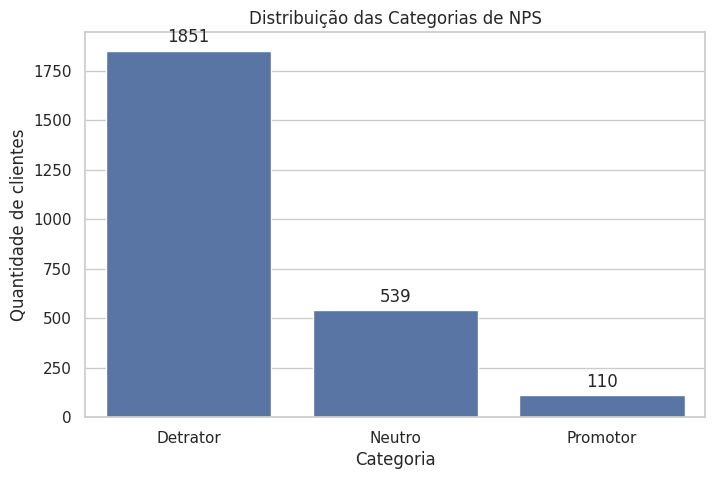

,nps_category,qtd_clientes,percentual
0,Detrator,1851,74.0
1,Neutro,539,21.6
2,Promotor,110,4.4


In [ ]:
cat_pd = sql_to_pandas("""
SELECT
    nps_category,
    COUNT(*) AS qtd_clientes,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS percentual
FROM nps_eda
GROUP BY nps_category
ORDER BY CASE nps_category WHEN 'Detrator' THEN 1 WHEN 'Neutro' THEN 2 ELSE 3 END
""")

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=cat_pd, x="nps_category", y="qtd_clientes")
add_labels(ax)
plt.title("Distribuição das Categorias de NPS")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de clientes")
plt.show()

cat_pd

### Storytelling

Os detratores representam **74,0% da base**. A prioridade do negócio deve ser atacar os fatores que fazem a experiência virar detratora, especialmente falhas de entrega e atendimento.

## 7. Atraso de entrega

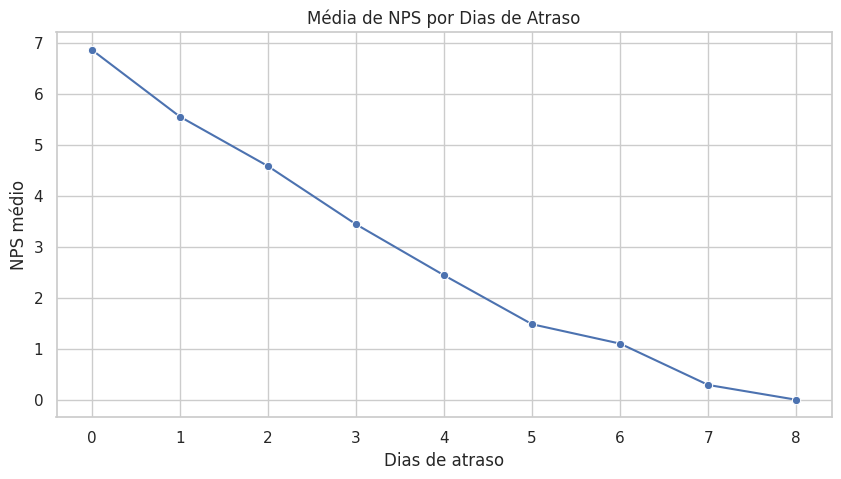

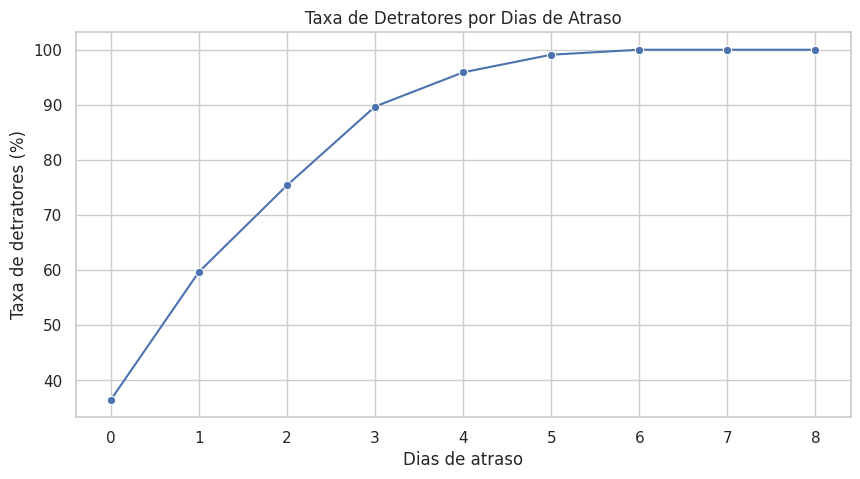

,delivery_delay_days,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,0,277,6.86,36.5,33.9
1,1,615,5.55,59.7,14.8
2,2,646,4.58,75.4,4.0
3,3,525,3.44,89.7,1.1
4,4,270,2.44,95.9,0.4
5,5,116,1.48,99.1,0.0
6,6,34,1.10,100.0,0.0
7,7,14,0.29,100.0,0.0
8,8,3,0.00,100.0,0.0


In [ ]:
atraso_pd = sql_to_pandas("""
SELECT
    delivery_delay_days,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator,
    ROUND(AVG(repeat_purchase_30d) * 100, 1) AS taxa_recompra_30d
FROM nps_eda
GROUP BY delivery_delay_days
ORDER BY delivery_delay_days
""")

plt.figure(figsize=(10, 5))
sns.lineplot(data=atraso_pd, x="delivery_delay_days", y="media_nps", marker="o")
plt.title("Média de NPS por Dias de Atraso")
plt.xlabel("Dias de atraso")
plt.ylabel("NPS médio")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=atraso_pd, x="delivery_delay_days", y="taxa_detrator", marker="o")
plt.title("Taxa de Detratores por Dias de Atraso")
plt.xlabel("Dias de atraso")
plt.ylabel("Taxa de detratores (%)")
plt.show()

atraso_pd

### Storytelling

Clientes sem atraso têm NPS médio de **6,86** e taxa de detratores de **36,5%**. Quando o atraso chega a **3 dias ou mais**, o NPS médio cai para **2,78** e a taxa de detratores sobe para **93,1%**.

**Conclusão prática:** 3+ dias de atraso é um ponto de ruptura. A logística deve criar alertas e ações proativas antes dessa marca.

## 8. Contatos com suporte

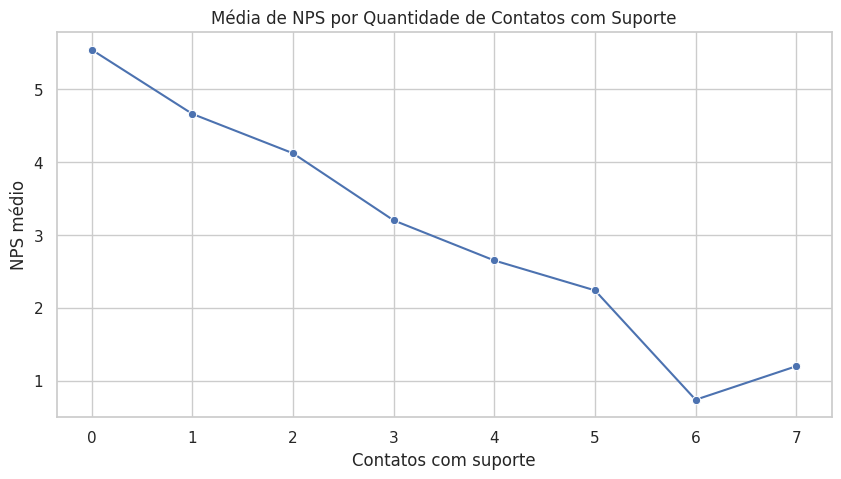

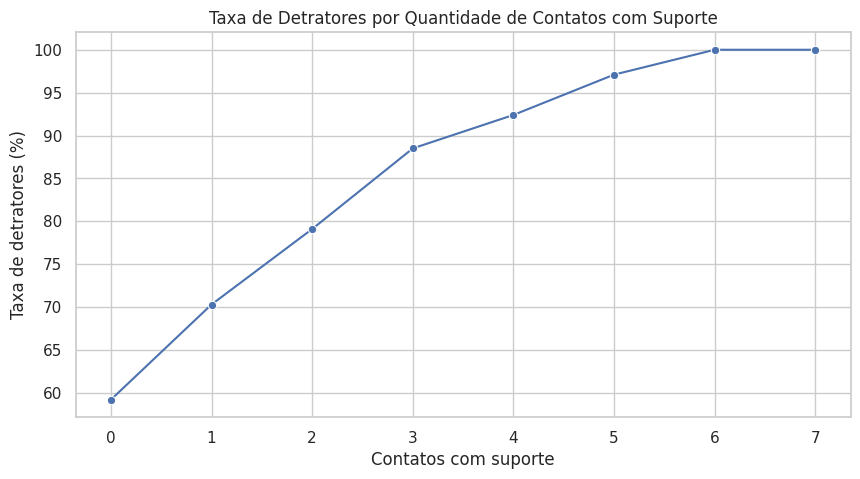

,customer_service_contacts,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,0,554,5.54,59.2,17.9
1,1,816,4.66,70.3,9.2
2,2,640,4.12,79.1,5.3
3,3,314,3.20,88.5,2.9
4,4,132,2.65,92.4,0.8
5,5,34,2.24,97.1,0.0
6,6,7,0.74,100.0,0.0
7,7,3,1.20,100.0,0.0


In [ ]:
contatos_pd = sql_to_pandas("""
SELECT
    customer_service_contacts,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator,
    ROUND(AVG(repeat_purchase_30d) * 100, 1) AS taxa_recompra_30d
FROM nps_eda
GROUP BY customer_service_contacts
ORDER BY customer_service_contacts
""")

plt.figure(figsize=(10, 5))
sns.lineplot(data=contatos_pd, x="customer_service_contacts", y="media_nps", marker="o")
plt.title("Média de NPS por Quantidade de Contatos com Suporte")
plt.xlabel("Contatos com suporte")
plt.ylabel("NPS médio")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=contatos_pd, x="customer_service_contacts", y="taxa_detrator", marker="o")
plt.title("Taxa de Detratores por Quantidade de Contatos com Suporte")
plt.xlabel("Contatos com suporte")
plt.ylabel("Taxa de detratores (%)")
plt.show()

contatos_pd

### Storytelling

Clientes sem contato com suporte têm NPS médio de **5,54**. Com **3 ou mais contatos**, o NPS médio cai para **2,94** e a taxa de detratores chega a **90,4%**.

**Conclusão prática:** o 2º contato deveria acionar escalonamento preventivo, antes que o cliente chegue ao 3º contato.

## 9. Reclamações

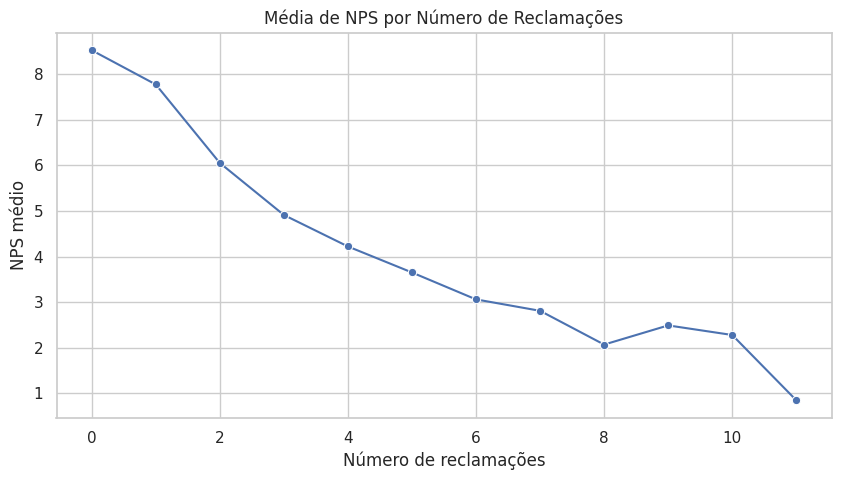

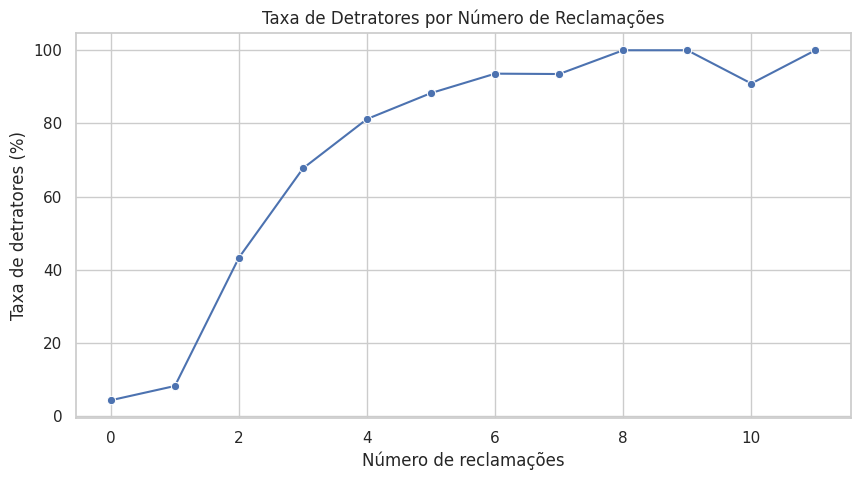

,complaints_count,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,0,23,8.52,4.3,69.6
1,1,122,7.77,8.2,42.6
2,2,277,6.05,43.3,19.5
3,3,507,4.91,67.7,8.9
4,4,600,4.22,81.2,6.0
5,5,444,3.65,88.3,2.0
6,6,266,3.06,93.6,0.4
7,7,169,2.81,93.5,2.4
8,8,63,2.07,100.0,0.0
9,9,16,2.49,100.0,0.0


In [ ]:
reclamacoes_pd = sql_to_pandas("""
SELECT
    complaints_count,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator,
    ROUND(AVG(repeat_purchase_30d) * 100, 1) AS taxa_recompra_30d
FROM nps_eda
GROUP BY complaints_count
ORDER BY complaints_count
""")

plt.figure(figsize=(10, 5))
sns.lineplot(data=reclamacoes_pd, x="complaints_count", y="media_nps", marker="o")
plt.title("Média de NPS por Número de Reclamações")
plt.xlabel("Número de reclamações")
plt.ylabel("NPS médio")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=reclamacoes_pd, x="complaints_count", y="taxa_detrator", marker="o")
plt.title("Taxa de Detratores por Número de Reclamações")
plt.xlabel("Número de reclamações")
plt.ylabel("Taxa de detratores (%)")
plt.show()

reclamacoes_pd

### Storytelling

Clientes com **0 reclamações** têm NPS médio de **8,52**. Com **3 a 4 reclamações**, a taxa de detratores já chega a **75,0%**. Com **5 ou mais reclamações**, a taxa passa de **88%**.

**Conclusão prática:** 5+ reclamações devem acionar uma tratativa especial e análise de causa raiz.

## 10. Tempo de resolução

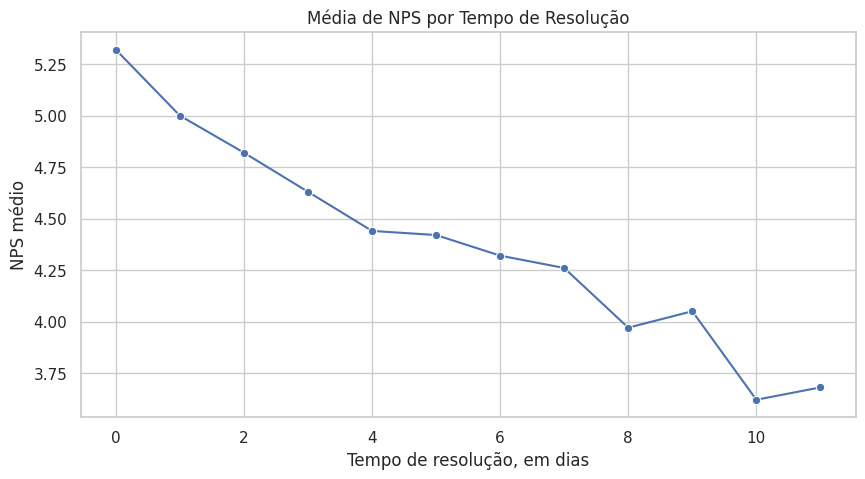

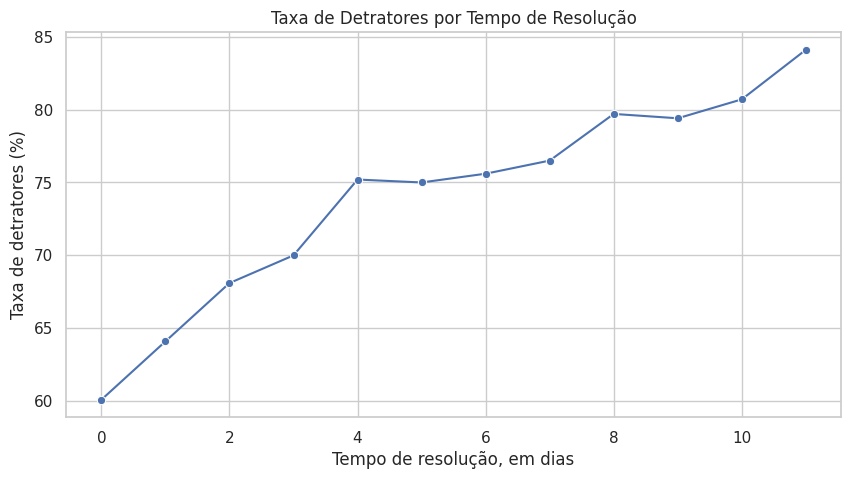

,resolution_time_days,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,0,208,5.32,60.1,14.4
1,1,192,5.00,64.1,13.5
2,2,229,4.82,68.1,10.9
3,3,237,4.63,70.0,13.9
4,4,206,4.44,75.2,9.7
5,5,176,4.42,75.0,5.7
6,6,197,4.32,75.6,10.2
7,7,213,4.26,76.5,7.0
8,8,227,3.97,79.7,4.8
9,9,204,4.05,79.4,4.9


In [ ]:
resolucao_pd = sql_to_pandas("""
SELECT
    resolution_time_days,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator,
    ROUND(AVG(repeat_purchase_30d) * 100, 1) AS taxa_recompra_30d
FROM nps_eda
GROUP BY resolution_time_days
ORDER BY resolution_time_days
""")

plt.figure(figsize=(10, 5))
sns.lineplot(data=resolucao_pd, x="resolution_time_days", y="media_nps", marker="o")
plt.title("Média de NPS por Tempo de Resolução")
plt.xlabel("Tempo de resolução, em dias")
plt.ylabel("NPS médio")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=resolucao_pd, x="resolution_time_days", y="taxa_detrator", marker="o")
plt.title("Taxa de Detratores por Tempo de Resolução")
plt.xlabel("Tempo de resolução, em dias")
plt.ylabel("Taxa de detratores (%)")
plt.show()

resolucao_pd

### Storytelling

O tempo de resolução afeta a satisfação de forma gradual. Com resolução acima de **10 dias**, a taxa de detratores chega a **82,5%**.

**Conclusão prática:** casos próximos de 10 dias devem ter alerta de SLA e priorização.

## 11. Recompra em até 30 dias por categoria de NPS

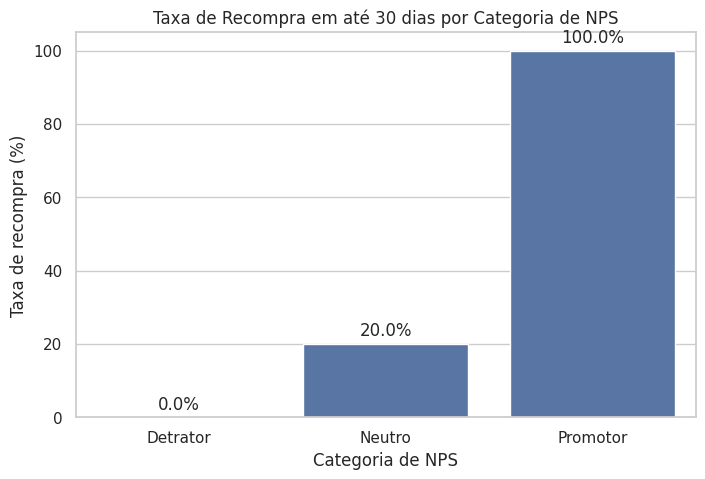

,nps_category,qtd_clientes,taxa_recompra_30d,media_nps
0,Detrator,1851,0.0,3.26
1,Neutro,539,20.0,7.16
2,Promotor,110,100.0,9.61


In [ ]:
recompra_pd = sql_to_pandas("""
SELECT
    nps_category,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(repeat_purchase_30d) * 100, 1) AS taxa_recompra_30d,
    ROUND(AVG(nps_score), 2) AS media_nps
FROM nps_eda
GROUP BY nps_category
ORDER BY CASE nps_category WHEN 'Detrator' THEN 1 WHEN 'Neutro' THEN 2 ELSE 3 END
""")

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=recompra_pd, x="nps_category", y="taxa_recompra_30d")
add_labels(ax, fmt="{:.1f}%")
plt.title("Taxa de Recompra em até 30 dias por Categoria de NPS")
plt.xlabel("Categoria de NPS")
plt.ylabel("Taxa de recompra (%)")
plt.show()

recompra_pd

### Storytelling

Na base analisada, detratores praticamente não recompram em até 30 dias, enquanto promotores apresentam recompra muito alta. Isso reforça a conexão entre experiência, retenção e receita futura.


## 12. Perfil do cliente: região, idade, relacionamento e valor do pedido

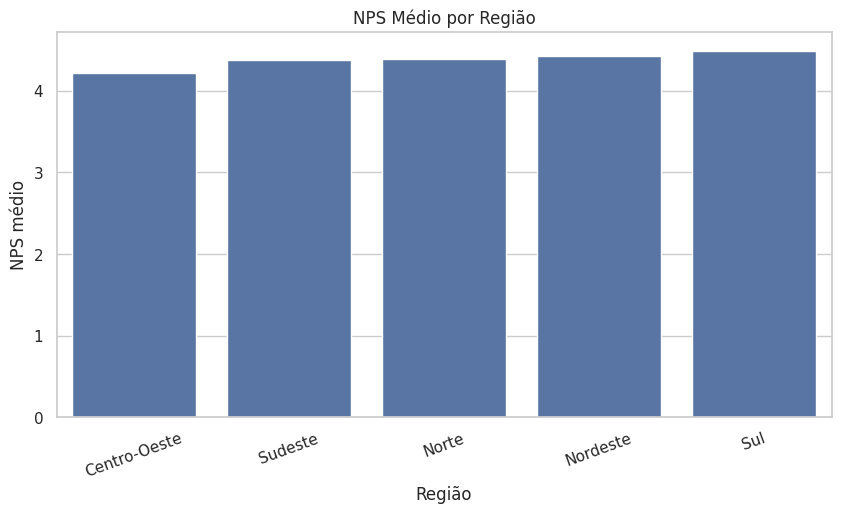

,customer_region,qtd_clientes,media_nps,taxa_detrator,atraso_medio,contatos_medios,reclamacoes_medias
0,Centro-Oeste,468,4.21,74.4,2.22,1.59,4.18
1,Sudeste,520,4.37,74.6,2.22,1.49,4.24
2,Norte,506,4.38,74.5,2.14,1.46,4.11
3,Nordeste,485,4.42,74.0,2.19,1.51,4.16
4,Sul,521,4.49,72.7,2.17,1.55,4.06


In [ ]:
perfil_regiao_pd = sql_to_pandas("""
SELECT
    customer_region,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator,
    ROUND(AVG(delivery_delay_days), 2) AS atraso_medio,
    ROUND(AVG(customer_service_contacts), 2) AS contatos_medios,
    ROUND(AVG(complaints_count), 2) AS reclamacoes_medias
FROM nps_eda
GROUP BY customer_region
ORDER BY media_nps
""")

plt.figure(figsize=(10, 5))
sns.barplot(data=perfil_regiao_pd, x="customer_region", y="media_nps")
plt.title("NPS Médio por Região")
plt.xlabel("Região")
plt.ylabel("NPS médio")
plt.xticks(rotation=20)
plt.show()

perfil_regiao_pd

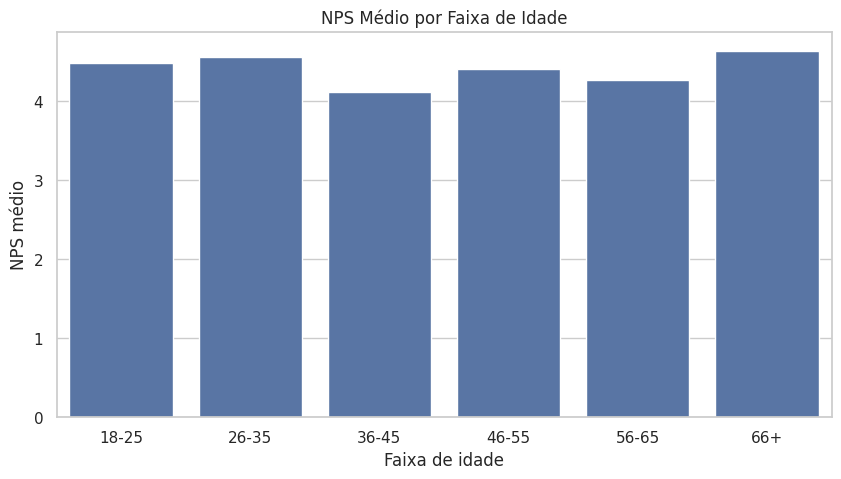

,faixa_idade,qtd_clientes,media_nps,taxa_detrator
0,18-25,389,4.48,75.8
1,26-35,465,4.56,71.0
2,36-45,517,4.12,77.6
3,46-55,468,4.41,72.0
4,56-65,476,4.27,75.4
5,66+,185,4.64,69.7


In [ ]:
perfil_idade_pd = sql_to_pandas("""
SELECT
    faixa_idade,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator
FROM nps_eda
GROUP BY faixa_idade
ORDER BY CASE faixa_idade
    WHEN '18-25' THEN 1 WHEN '26-35' THEN 2 WHEN '36-45' THEN 3
    WHEN '46-55' THEN 4 WHEN '56-65' THEN 5 ELSE 6 END
""")

plt.figure(figsize=(10, 5))
sns.barplot(data=perfil_idade_pd, x="faixa_idade", y="media_nps")
plt.title("NPS Médio por Faixa de Idade")
plt.xlabel("Faixa de idade")
plt.ylabel("NPS médio")
plt.show()

perfil_idade_pd

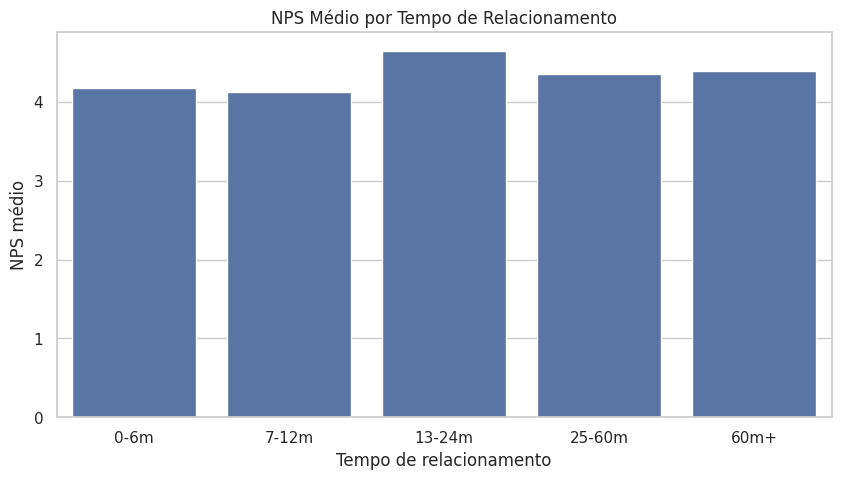

,faixa_relacionamento,qtd_clientes,media_nps,taxa_detrator
0,0-6m,122,4.17,77.0
1,7-12m,120,4.12,75.0
2,13-24m,247,4.65,71.7
3,25-60m,721,4.35,74.1
4,60m+,1290,4.39,74.1


In [ ]:
perfil_relacionamento_pd = sql_to_pandas("""
SELECT
    faixa_relacionamento,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator
FROM nps_eda
GROUP BY faixa_relacionamento
ORDER BY CASE faixa_relacionamento
    WHEN '0-6m' THEN 1 WHEN '7-12m' THEN 2 WHEN '13-24m' THEN 3
    WHEN '25-60m' THEN 4 ELSE 5 END
""")

plt.figure(figsize=(10, 5))
sns.barplot(data=perfil_relacionamento_pd, x="faixa_relacionamento", y="media_nps")
plt.title("NPS Médio por Tempo de Relacionamento")
plt.xlabel("Tempo de relacionamento")
plt.ylabel("NPS médio")
plt.show()

perfil_relacionamento_pd

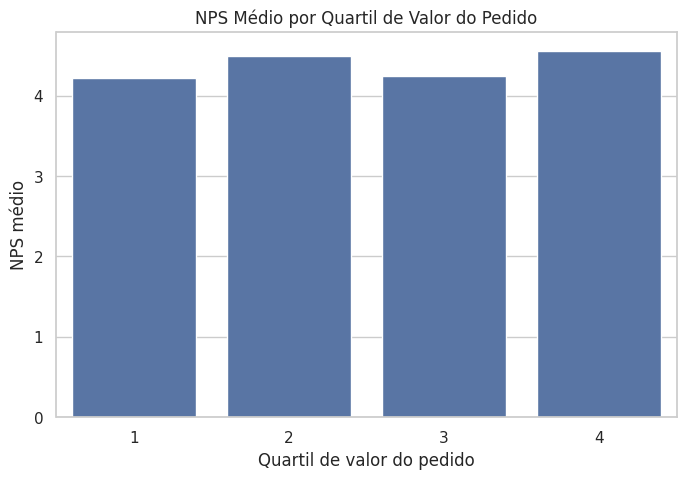

,quartil_valor_pedido,qtd_clientes,valor_min,valor_max,valor_medio,media_nps,taxa_detrator
0,1,625,7.76,220.20,137.42,4.22,76.0
1,2,625,220.26,375.46,296.49,4.49,73.4
2,3,625,375.57,577.20,466.23,4.25,74.9
3,4,625,577.56,1983.81,836.90,4.56,71.8


In [ ]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW nps_eda_quartil AS
SELECT *, NTILE(4) OVER (ORDER BY order_value) AS quartil_valor_pedido
FROM nps_eda
""")

valor_pd = sql_to_pandas("""
SELECT
    quartil_valor_pedido,
    COUNT(*) AS qtd_clientes,
    ROUND(MIN(order_value), 2) AS valor_min,
    ROUND(MAX(order_value), 2) AS valor_max,
    ROUND(AVG(order_value), 2) AS valor_medio,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator
FROM nps_eda_quartil
GROUP BY quartil_valor_pedido
ORDER BY quartil_valor_pedido
""")

plt.figure(figsize=(8, 5))
sns.barplot(data=valor_pd, x="quartil_valor_pedido", y="media_nps")
plt.title("NPS Médio por Quartil de Valor do Pedido")
plt.xlabel("Quartil de valor do pedido")
plt.ylabel("NPS médio")
plt.show()

valor_pd

### Storytelling

As diferenças por região, idade, relacionamento e valor do pedido são menores do que as diferenças operacionais. O problema parece estar mais na **execução da jornada** do que em um perfil demográfico específico.

## 13. Correlação e variáveis mais importantes

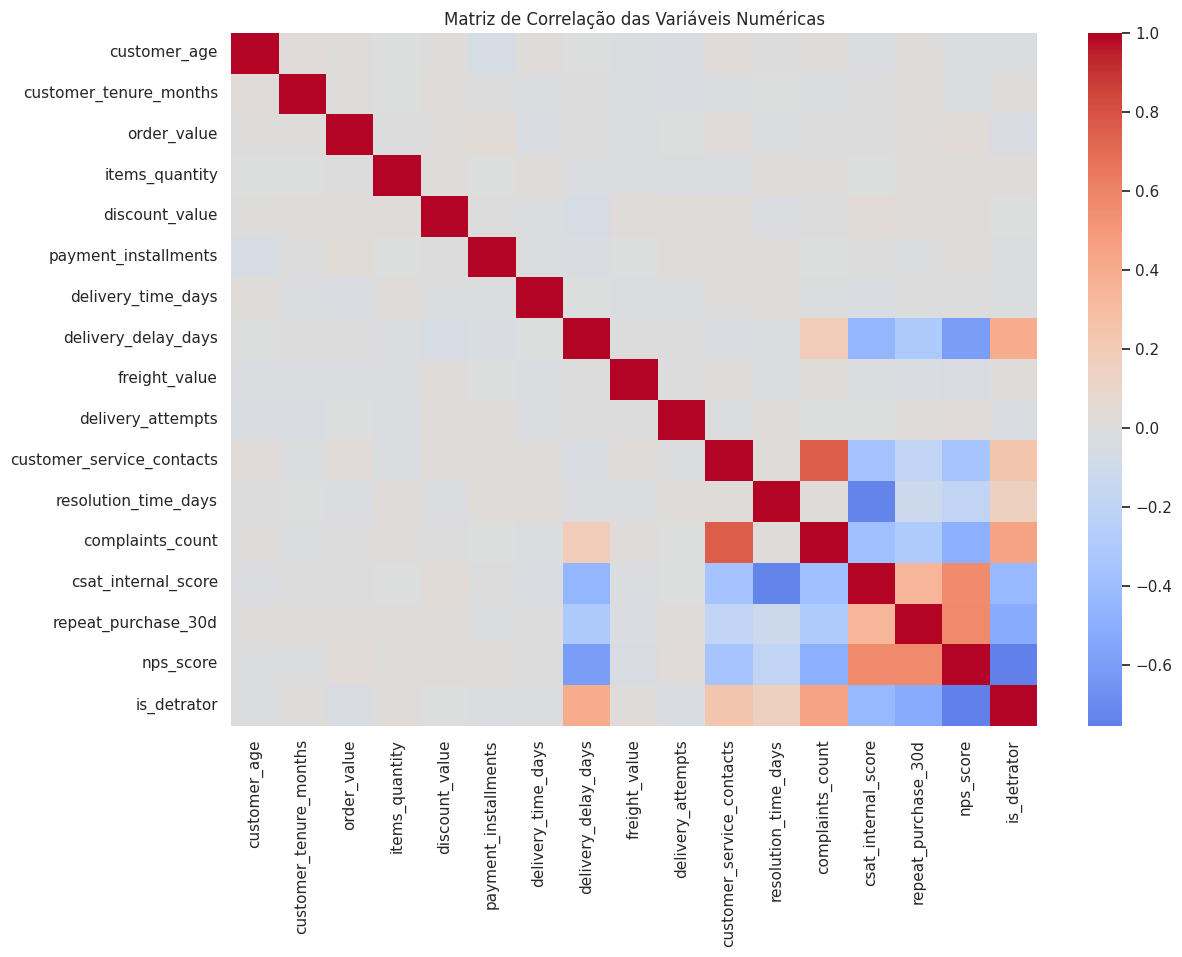

,nps_score,is_detrator
is_detrator,-0.754261,1.000000
delivery_delay_days,-0.597260,0.403119
complaints_count,-0.496800,0.447328
customer_service_contacts,-0.350845,0.239509
resolution_time_days,-0.191392,0.150463
freight_value,-0.041087,0.025748
customer_age,-0.009936,-0.009807
customer_tenure_months,-0.009711,0.012393
delivery_time_days,0.000925,-0.011792
items_quantity,0.011468,0.024094


In [ ]:
numericas_pd = sql_to_pandas("""
SELECT
    customer_age,
    customer_tenure_months,
    order_value,
    items_quantity,
    discount_value,
    payment_installments,
    delivery_time_days,
    delivery_delay_days,
    freight_value,
    delivery_attempts,
    customer_service_contacts,
    resolution_time_days,
    complaints_count,
    csat_internal_score,
    repeat_purchase_30d,
    nps_score,
    is_detrator
FROM nps_eda
""")

corr = numericas_pd.corr(numeric_only=True)
plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

corr[["nps_score", "is_detrator"]].sort_values("nps_score")

### Storytelling

As variáveis operacionais mais relevantes para futura modelagem são `delivery_delay_days`, `complaints_count`, `customer_service_contacts` e `resolution_time_days`. `repeat_purchase_30d` e `csat_internal_score` têm relação forte com NPS, mas exigem cuidado por possível **data leakage**.

## 14. Boxplots: detratores vs. não-detratores

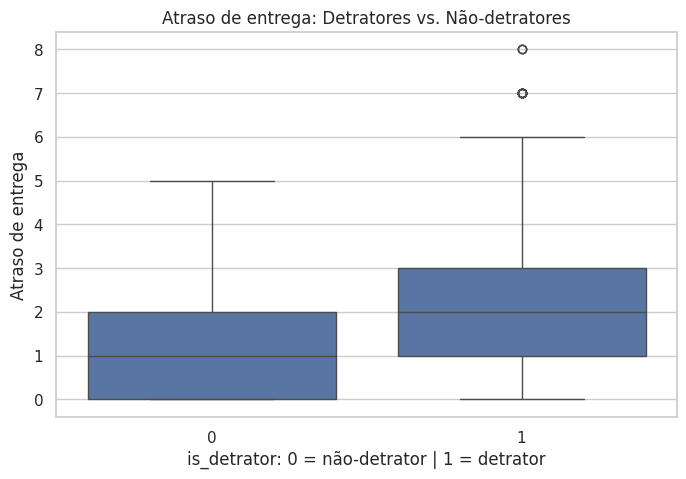

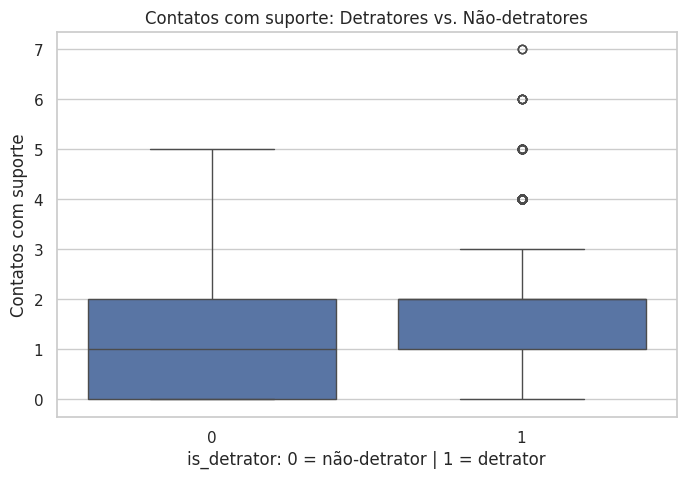

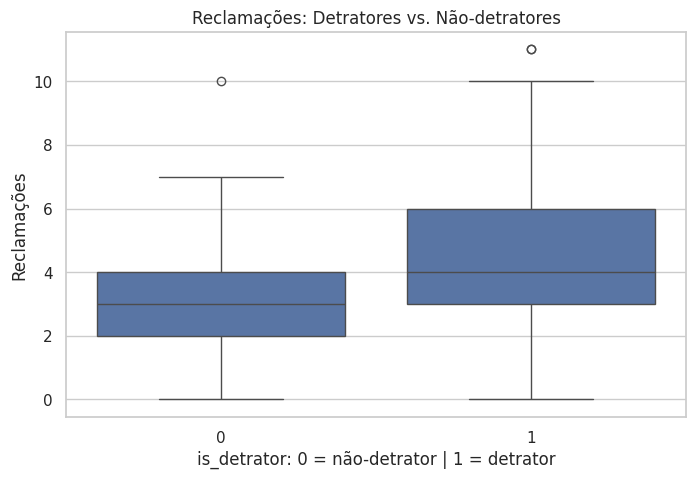

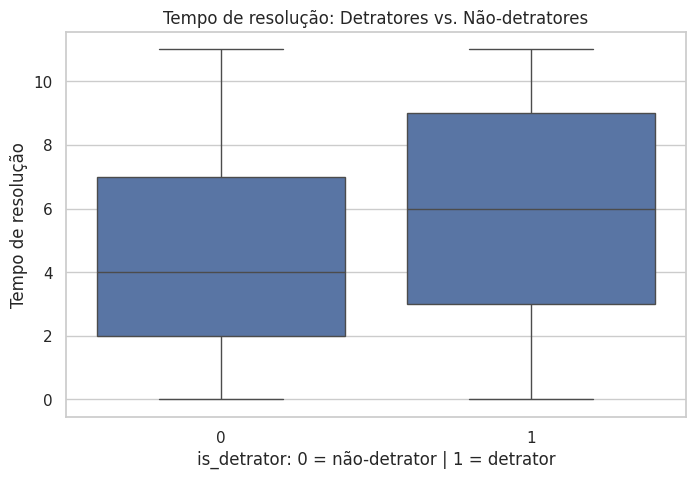

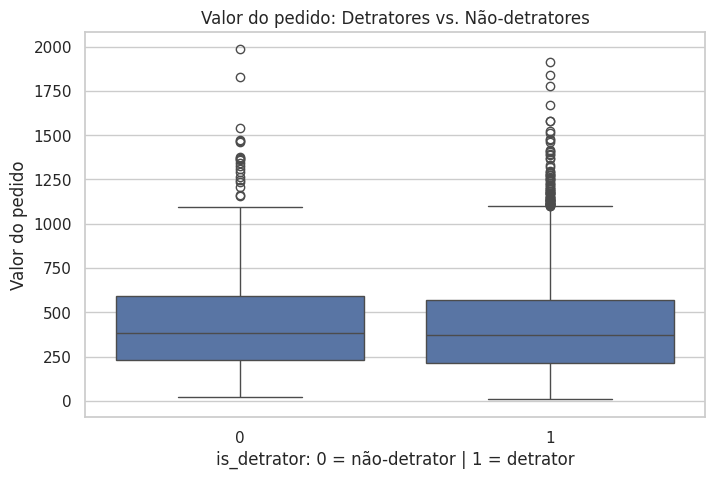

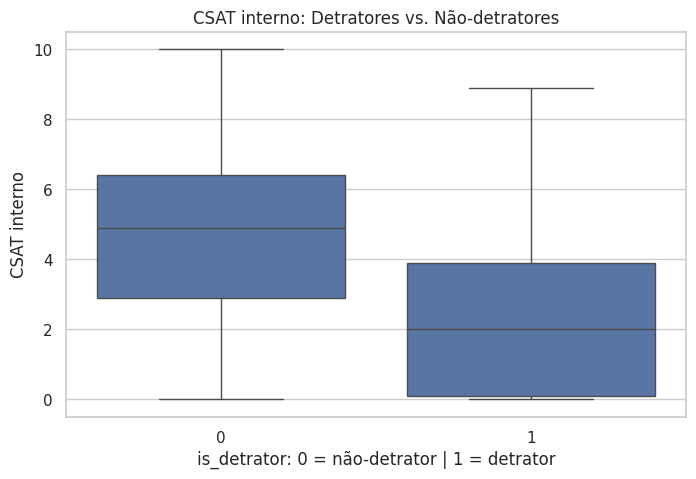

In [ ]:
box_pd = sql_to_pandas("""
SELECT
    is_detrator,
    delivery_delay_days,
    customer_service_contacts,
    complaints_count,
    resolution_time_days,
    order_value,
    csat_internal_score
FROM nps_eda
""")

for col_name, title in [
    ("delivery_delay_days", "Atraso de entrega"),
    ("customer_service_contacts", "Contatos com suporte"),
    ("complaints_count", "Reclamações"),
    ("resolution_time_days", "Tempo de resolução"),
    ("order_value", "Valor do pedido"),
    ("csat_internal_score", "CSAT interno")
]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=box_pd, x="is_detrator", y=col_name)
    plt.title(f"{title}: Detratores vs. Não-detratores")
    plt.xlabel("is_detrator: 0 = não-detrator | 1 = detrator")
    plt.ylabel(title)
    plt.show()

### Storytelling

Detratores concentram mais atraso, mais reclamações, mais contatos e maior tempo de resolução. Valor do pedido não separa bem detratores de não-detratores, indicando que o ticket não é o principal problema.

## 15. Pontos de ruptura

In [ ]:
ruptura_atraso_pd = sql_to_pandas("""
SELECT faixa_atraso, COUNT(*) qtd_clientes, ROUND(AVG(nps_score),2) media_nps,
       ROUND(AVG(is_detrator)*100,1) taxa_detrator,
       ROUND(AVG(repeat_purchase_30d)*100,1) taxa_recompra_30d
FROM nps_eda
GROUP BY faixa_atraso
ORDER BY CASE faixa_atraso WHEN '0 dias' THEN 1 WHEN '1 dia' THEN 2 WHEN '2 dias' THEN 3 ELSE 4 END
""")

ruptura_contatos_pd = sql_to_pandas("""
SELECT faixa_contatos, COUNT(*) qtd_clientes, ROUND(AVG(nps_score),2) media_nps,
       ROUND(AVG(is_detrator)*100,1) taxa_detrator,
       ROUND(AVG(repeat_purchase_30d)*100,1) taxa_recompra_30d
FROM nps_eda
GROUP BY faixa_contatos
ORDER BY CASE faixa_contatos WHEN '0 contatos' THEN 1 WHEN '1 contato' THEN 2 WHEN '2 contatos' THEN 3 ELSE 4 END
""")

ruptura_reclamacoes_pd = sql_to_pandas("""
SELECT faixa_reclamacoes, COUNT(*) qtd_clientes, ROUND(AVG(nps_score),2) media_nps,
       ROUND(AVG(is_detrator)*100,1) taxa_detrator,
       ROUND(AVG(repeat_purchase_30d)*100,1) taxa_recompra_30d
FROM nps_eda
GROUP BY faixa_reclamacoes
ORDER BY CASE faixa_reclamacoes WHEN '0' THEN 1 WHEN '1-2' THEN 2 WHEN '3-4' THEN 3 WHEN '5-6' THEN 4 ELSE 5 END
""")

ruptura_resolucao_pd = sql_to_pandas("""
SELECT faixa_resolucao, COUNT(*) qtd_clientes, ROUND(AVG(nps_score),2) media_nps,
       ROUND(AVG(is_detrator)*100,1) taxa_detrator,
       ROUND(AVG(repeat_purchase_30d)*100,1) taxa_recompra_30d
FROM nps_eda
GROUP BY faixa_resolucao
ORDER BY CASE faixa_resolucao WHEN '0 dias' THEN 1 WHEN '1-3 dias' THEN 2 WHEN '4-6 dias' THEN 3 WHEN '7-9 dias' THEN 4 ELSE 5 END
""")

display(ruptura_atraso_pd)
display(ruptura_contatos_pd)
display(ruptura_reclamacoes_pd)
display(ruptura_resolucao_pd)

,faixa_atraso,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,0 dias,277,6.86,36.5,33.9
1,1 dia,615,5.55,59.7,14.8
2,2 dias,646,4.58,75.4,4.0
3,3+ dias,962,2.78,93.1,0.7


,faixa_contatos,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,0 contatos,554,5.54,59.2,17.9
1,1 contato,816,4.66,70.3,9.2
2,2 contatos,640,4.12,79.1,5.3
3,3+ contatos,490,2.94,90.4,2.0


,faixa_reclamacoes,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,0,23,8.52,4.3,69.6
1,1-2,399,6.58,32.6,26.6
2,3-4,1107,4.54,75.0,7.3
3,5-6,710,3.43,90.3,1.4
4,7+,261,2.58,95.4,1.9


,faixa_resolucao,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,0 dias,208,5.32,60.1,14.4
1,1-3 dias,658,4.80,67.6,12.8
2,4-6 dias,579,4.40,75.3,8.6
3,7-9 dias,644,4.09,78.6,5.6
4,10+ dias,411,3.65,82.5,4.4


### Pontos de ruptura identificados

| Fator | Ponto de ruptura | O que acontece | Ação preventiva sugerida |
|---|---|---|---|
| Atraso de entrega | **3+ dias** | Taxa de detratores chega a **93,1%** e recompra cai para **0,7%** | Priorizar pedido, comunicar proativamente e oferecer compensação |
| Contatos com suporte | **3+ contatos** | Taxa de detratores chega a **90,4%** | Escalonar no 2º contato e criar célula de resolução rápida |
| Reclamações | **5+ reclamações** | Taxa de detratores fica acima de **91%** | Tratativa especial e análise de causa raiz |
| Tempo de resolução | **10+ dias** | Taxa de detratores chega a **82,5%** | SLA máximo e alerta para casos parados |

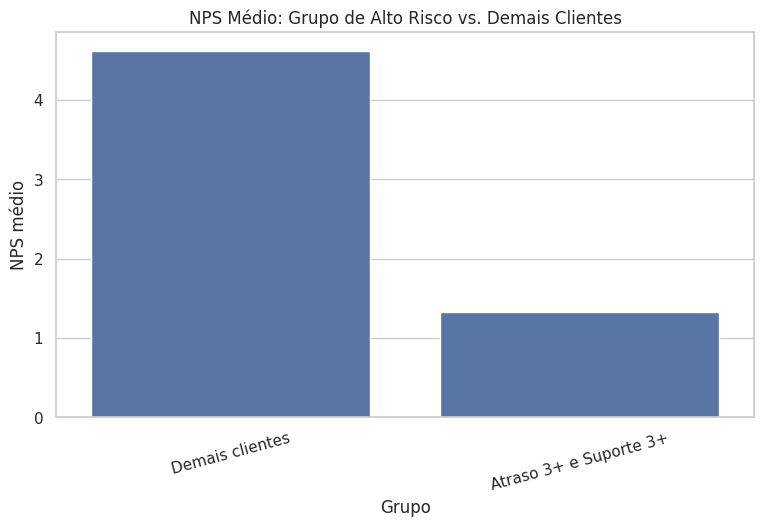

,grupo_risco,qtd_clientes,media_nps,taxa_detrator,taxa_recompra_30d
0,Demais clientes,2319,4.62,72.1,9.4
1,Atraso 3+ e Suporte 3+,181,1.33,99.4,0.0


In [ ]:
alto_risco_pd = sql_to_pandas("""
SELECT
    CASE WHEN delivery_delay_days >= 3 AND customer_service_contacts >= 3
         THEN 'Atraso 3+ e Suporte 3+'
         ELSE 'Demais clientes'
    END AS grupo_risco,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator,
    ROUND(AVG(repeat_purchase_30d) * 100, 1) AS taxa_recompra_30d
FROM nps_eda
GROUP BY grupo_risco
ORDER BY grupo_risco DESC
""")

plt.figure(figsize=(9, 5))
sns.barplot(data=alto_risco_pd, x="grupo_risco", y="media_nps")
plt.title("NPS Médio: Grupo de Alto Risco vs. Demais Clientes")
plt.xlabel("Grupo")
plt.ylabel("NPS médio")
plt.xticks(rotation=15)
plt.show()

alto_risco_pd

### Ponto crítico combinado

Quando o cliente tem **3+ dias de atraso** e **3+ contatos com suporte**, o NPS médio cai para **1,33** e a taxa de detratores chega a **99,4%**. Esse é o melhor gatilho operacional para uma ação preventiva prioritária.

## 16. Feature Engineering

In [ ]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW nps_features AS
SELECT
    base.*,
    CASE WHEN risco_operacional_score >= 3 THEN 'Alto'
         WHEN risco_operacional_score = 2 THEN 'Médio'
         WHEN risco_operacional_score = 1 THEN 'Baixo'
         ELSE 'Sem risco aparente'
    END AS risco_operacional
FROM (
    SELECT
        *,
        CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END AS teve_atraso,
        CASE WHEN delivery_delay_days >= 3 THEN 1 ELSE 0 END AS atraso_3_dias_ou_mais,
        CASE WHEN customer_service_contacts >= 3 THEN 1 ELSE 0 END AS muitos_contatos_suporte,
        CASE WHEN complaints_count > 0 THEN 1 ELSE 0 END AS teve_reclamacao,
        CASE WHEN complaints_count >= 5 THEN 1 ELSE 0 END AS muitas_reclamacoes,
        CASE WHEN resolution_time_days >= 10 THEN 1 ELSE 0 END AS tempo_resolucao_alto,
        CASE WHEN delivery_attempts >= 3 THEN 1 ELSE 0 END AS multiplas_tentativas_entrega,
        (
            CASE WHEN delivery_delay_days >= 3 THEN 1 ELSE 0 END +
            CASE WHEN customer_service_contacts >= 3 THEN 1 ELSE 0 END +
            CASE WHEN complaints_count >= 5 THEN 1 ELSE 0 END +
            CASE WHEN resolution_time_days >= 10 THEN 1 ELSE 0 END
        ) AS risco_operacional_score
    FROM nps_eda
) base
""")

spark.sql("""
SELECT
    risco_operacional,
    COUNT(*) AS qtd_clientes,
    ROUND(AVG(nps_score), 2) AS media_nps,
    ROUND(AVG(is_detrator) * 100, 1) AS taxa_detrator,
    ROUND(AVG(repeat_purchase_30d) * 100, 1) AS taxa_recompra_30d
FROM nps_features
GROUP BY risco_operacional
ORDER BY CASE risco_operacional
    WHEN 'Sem risco aparente' THEN 1 WHEN 'Baixo' THEN 2 WHEN 'Médio' THEN 3 ELSE 4 END
""").show()

+------------------+------------+---------+-------------+-----------------+
| risco_operacional|qtd_clientes|media_nps|taxa_detrator|taxa_recompra_30d|
+------------------+------------+---------+-------------+-----------------+
|Sem risco aparente|         808|     6.19|         46.7|             21.7|
|             Baixo|         861|     4.25|         80.0|              4.2|
|             Médio|         560|     3.28|         92.1|              1.3|
|              Alto|         271|     1.67|         99.3|              0.0|
+------------------+------------+---------+-------------+-----------------+



### Features sugeridas

| Feature | Como criar | Por que faz sentido | Como ajuda o modelo |
|---|---|---|---|
| `teve_atraso` | `delivery_delay_days > 0` | Separa pedidos no prazo dos atrasados | Captura atrito logístico inicial |
| `atraso_3_dias_ou_mais` | `delivery_delay_days >= 3` | 3+ dias é o principal ponto de ruptura | Sinal forte de risco de detrator |
| `muitos_contatos_suporte` | `customer_service_contacts >= 3` | 3+ contatos indica problema não resolvido | Captura falha no atendimento |
| `teve_reclamacao` | `complaints_count > 0` | Reclamação é atrito explícito | Diferencia clientes com problema declarado |
| `muitas_reclamacoes` | `complaints_count >= 5` | 5+ reclamações indicam risco crítico | Ajuda a priorizar casos graves |
| `tempo_resolucao_alto` | `resolution_time_days >= 10` | 10+ dias aumenta desgaste | Captura demora operacional |
| `risco_operacional_score` | Soma dos sinais críticos | Combina logística, suporte e reclamações | Cria score interpretável de risco |
| `risco_operacional` | Faixa do score | Traduz risco para o negócio | Facilita ação gerencial |

## 17. Data Leakage

Variáveis que **não devem entrar como features**:

| Coluna | Decisão | Motivo |
|---|---|---|
| `nps_score` | Remover | É a resposta que o modelo tenta prever |
| `is_detrator` | Remover | É o target derivado do NPS |
| `nps_category` | Remover | Também deriva do NPS |
| `customer_id` | Remover | Identificador, não comportamento |
| `order_id` | Remover | Identificador, não comportamento |

Variáveis a **investigar antes da modelagem**:

| Coluna | Risco | Recomendação |
|---|---|---|
| `repeat_purchase_30d` | Alto | Provavelmente ocorre depois da pesquisa; usar na EDA, mas remover do modelo preditivo se a previsão for antes da recompra |
| `csat_internal_score` | Médio/alto | Pode ser proxy direto de satisfação; confirmar momento de coleta |
| `resolution_time_days` | Médio | Usar apenas se conhecido antes da previsão |
| `complaints_count` | Médio | Usar apenas se representa reclamações acumuladas até o momento da previsão |

## 18. Conclusão executiva

**Fatores mais críticos:** atraso de entrega, reclamações, contatos com suporte e tempo de resolução.

**O que mais gera detratores:** a combinação de falha logística com falha de atendimento. Clientes com **3+ dias de atraso** e **3+ contatos com suporte** chegam a **99,4% de detratores**.

**Principal ponto de ruptura:** **3 ou mais dias de atraso**. A partir desse ponto, o NPS médio cai muito e a recompra praticamente desaparece.

**Perfil com NPS menor:** clientes com mais falhas operacionais. As diferenças por região, idade, relacionamento e valor do pedido são pequenas em comparação aos efeitos de atraso, reclamação e suporte.

**Recomendações práticas:**

1. Criar alerta automático para pedidos com tendência de **3+ dias de atraso**.
2. Escalonar atendimento no **2º contato**.
3. Criar fila prioritária para clientes com **5+ reclamações**.
4. Monitorar casos com **10+ dias de resolução**.
5. Usar `risco_operacional_score` para priorizar ações antes da pesquisa de NPS.